<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
text-align:center;
font-size:34px;
">
Tareas 25.04.2026
</h2>

</div>

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Método Newton
</h2>

</div>

In [5]:
import numpy as np

# Función 
def A(theta):
    return 4*np.sin(theta)*(1 + np.cos(theta))

# 1ra der
def dA(theta):
    return 4*(np.cos(theta) + np.cos(2*theta))

# 2da der
def ddA(theta):
    return 4*(-np.sin(theta) - 2*np.sin(2*theta))

# Método de Newton para opti
theta = np.radians(45)   # valor inicial del ejercicio: 45 gra
epsilon = 0.05
error = 1
iteracion = 0

print("Método de Newton para maximizar A(theta)\n")

while error > epsilon:
    theta_nuevo = theta - dA(theta)/ddA(theta)
    error = abs(theta_nuevo - theta)

    print(f"Iteración {iteracion+1}")
    print(f"theta = {theta_nuevo:.6f} rad")
    print(f"theta = {np.degrees(theta_nuevo):.4f} grados")
    print(f"A(theta) = {A(theta_nuevo):.6f}")
    print(f"error = {error:.6f}\n")

    theta = theta_nuevo
    iteracion += 1

print("Resultado final:")
print(f"theta óptimo = {theta:.6f} rad")
print(f"theta óptimo = {np.degrees(theta):.4f} grados")
print(f"Área máxima = {A(theta):.6f}")

Método de Newton para maximizar A(theta)

Iteración 1
theta = 1.046602 rad
theta = 59.9659 grados
A(theta) = 5.196151
error = 0.261204

Iteración 2
theta = 1.047197 rad
theta = 60.0000 grados
A(theta) = 5.196152
error = 0.000595

Resultado final:
theta óptimo = 1.047197 rad
theta óptimo = 60.0000 grados
Área máxima = 5.196152


<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Maximizar el área de un canal
</h2>

</div>

In [2]:
import numpy as np
from scipy.optimize import minimize

def area(x):
    l, theta = x
    return (18 - 2*l + 2*l*np.cos(theta)) * l * np.sin(theta)

def objetivo(x):
    return -area(x)

# Punto inicial
x0 = [0, np.pi/6]

bounds = [(0, 9), (0, np.pi/2)]

#optimización
resultado = minimize(
    objetivo,
    x0,
    bounds=bounds,
    method="Nelder-Mead",
    options={"xatol": 0.05, "fatol": 0.05}
)

# Resul
l_opt, theta_opt = resultado.x
A_max = area(resultado.x)

print("Resultado de la maximización:")
print(f"l óptimo = {l_opt:.4f} cm")
print(f"theta óptimo = {theta_opt:.4f} rad")
print(f"theta óptimo = {np.degrees(theta_opt):.2f} grados")
print(f"Área máxima = {A_max:.4f} cm²")

Resultado de la maximización:
l óptimo = 0.0003 cm
theta óptimo = 0.5236 rad
theta óptimo = 30.00 grados
Área máxima = 0.0022 cm²


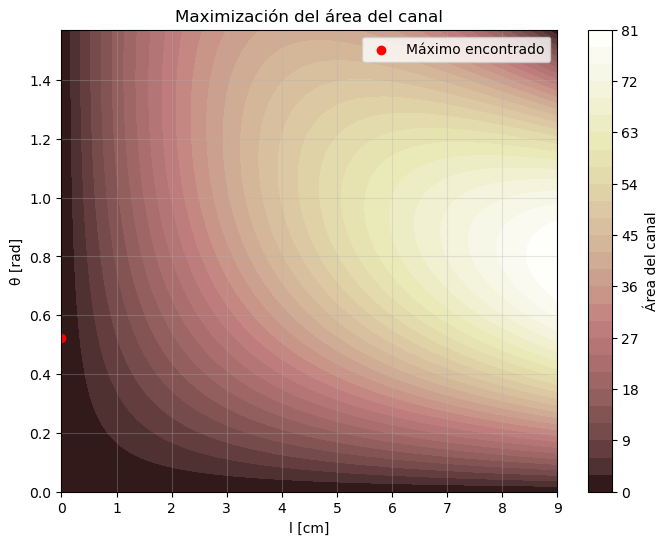

In [3]:
import matplotlib.pyplot as plt

l_vals = np.linspace(0, 9, 100)
theta_vals = np.linspace(0, np.pi/2, 100)

L, THETA = np.meshgrid(l_vals, theta_vals)
A = (18 - 2*L + 2*L*np.cos(THETA)) * L * np.sin(THETA)

plt.figure(figsize=(8,6))
contour = plt.contourf(L, THETA, A, levels=30, cmap="pink")
plt.colorbar(contour, label="Área del canal")

plt.scatter(l_opt, theta_opt, color="red", label="Máximo encontrado")

plt.xlabel("l [cm]")
plt.ylabel("θ [rad]")
plt.title("Maximización del área del canal")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Sección áurea
</h2>

</div>

In [6]:
import numpy as np

#f del área
def A(theta):
    return 4*np.sin(theta)*(1 + np.cos(theta))

# Inter ini
a = 0
b = np.pi/2


epsilon = 0.05

# Razón áurea
phi = (1 + np.sqrt(5)) / 2

x1 = b - (b - a)/phi
x2 = a + (b - a)/phi

iteracion = 0

print("Método de Sección Áurea para maximizar A(theta)\n")

while abs(b - a) > epsilon:
    print(f"Iteración {iteracion+1}")
    print(f"Intervalo: [{a:.6f}, {b:.6f}]")
    print(f"x1 = {x1:.6f}, A(x1) = {A(x1):.6f}")
    print(f"x2 = {x2:.6f}, A(x2) = {A(x2):.6f}\n")

   
    if A(x1) < A(x2):
        a = x1
        x1 = x2
        x2 = a + (b - a)/phi
    else:
        b = x2
        x2 = x1
        x1 = b - (b - a)/phi

    iteracion += 1

# Resul
theta_opt = (a + b) / 2
area_max = A(theta_opt)

print("Resultado final:")
print(f"theta óptimo = {theta_opt:.6f} rad")
print(f"theta óptimo = {np.degrees(theta_opt):.4f} grados")
print(f"Área máxima = {area_max:.6f}")

Método de Sección Áurea para maximizar A(theta)

Iteración 1
Intervalo: [0.000000, 1.570796]
x1 = 0.599991, A(x1) = 4.122604
x2 = 0.970806, A(x2) = 5.165428

Iteración 2
Intervalo: [0.599991, 1.570796]
x1 = 0.970806, A(x1) = 5.165428
x2 = 1.199982, A(x2) = 5.079110

Iteración 3
Intervalo: [0.599991, 1.199982]
x1 = 0.829167, A(x1) = 4.941818
x2 = 0.970806, A(x2) = 5.165428

Iteración 4
Intervalo: [0.829167, 1.199982]
x1 = 0.970806, A(x1) = 5.165428
x2 = 1.058343, A(x2) = 5.195508

Iteración 5
Intervalo: [0.970806, 1.199982]
x1 = 1.058343, A(x1) = 5.195508
x2 = 1.112444, A(x2) = 5.174333

Iteración 6
Intervalo: [0.970806, 1.112444]
x1 = 1.024907, A(x1) = 5.193560
x2 = 1.058343, A(x2) = 5.195508

Iteración 7
Intervalo: [1.024907, 1.112444]
x1 = 1.058343, A(x1) = 5.195508
x2 = 1.079008, A(x2) = 5.190928

Iteración 8
Intervalo: [1.024907, 1.079008]
x1 = 1.045571, A(x1) = 5.196139
x2 = 1.058343, A(x2) = 5.195508

Resultado final:
theta óptimo = 1.041625 rad
theta óptimo = 59.6807 grados
Área

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Luminosidad de un disco de acreción simplificado
</h2>

</div>

In [8]:
import numpy as np

def L(r, theta):
    return (r**2) * np.sin(theta) * (1 + np.cos(theta)) * np.exp(-r)

r_opt = 2
theta_opt = np.pi / 3

L_max = L(r_opt, theta_opt)

print("Solución")
print(f"r óptimo = {r_opt:.6f}")
print(f"theta óptimo = {theta_opt:.6f} rad")
print(f"theta óptimo = {np.degrees(theta_opt):.2f} grados")
print(f"Luminosidad máxima = {L_max:.6f}")

Solución exacta del ejercicio
r óptimo = 2.000000
theta óptimo = 1.047198 rad
theta óptimo = 60.00 grados
Luminosidad máxima = 0.703223


<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Método del gradiente
</h2>

</div>

In [9]:
import numpy as np

# f. de luminosidad
def L(r, theta):
    return (r**2) * np.sin(theta) * (1 + np.cos(theta)) * np.exp(-r)

# gra
def gradiente(r, theta):
    dL_dr = np.exp(-r) * np.sin(theta) * (1 + np.cos(theta)) * (2*r - r**2)
    
    dL_dtheta = (r**2) * np.exp(-r) * (np.cos(theta) + np.cos(2*theta))
    
    return np.array([dL_dr, dL_dtheta])

# elegi A: 
r = 1.0
theta = np.pi / 6

# datos
alpha = 0.1
epsilon = 0.05
max_iter = 100

print("CASO A: Método del gradiente")
print(f"r inicial = {r:.4f}")
print(f"theta inicial = {theta:.4f} rad")
print(f"theta inicial = {np.degrees(theta):.2f} grados\n")

for i in range(max_iter):
    
    grad = gradiente(r, theta)

    r_nuevo = r + alpha * grad[0]
    theta_nuevo = theta + alpha * grad[1]

    
    r_nuevo = np.clip(r_nuevo, 0.1, 5)
    theta_nuevo = np.clip(theta_nuevo, 0, np.pi/2)

    error = np.sqrt((r_nuevo - r)**2 + (theta_nuevo - theta)**2)

    print(f"Iteración {i+1}")
    print(f"r = {r_nuevo:.6f}")
    print(f"theta = {theta_nuevo:.6f} rad")
    print(f"theta = {np.degrees(theta_nuevo):.4f} grados")
    print(f"L(r, theta) = {L(r_nuevo, theta_nuevo):.6f}")
    print(f"error = {error:.6f}\n")

    r, theta = r_nuevo, theta_nuevo

    if error < epsilon:
        break

print("Resultado final:")
print(f"r óptimo = {r:.6f}")
print(f"theta óptimo = {theta:.6f} rad")
print(f"theta óptimo = {np.degrees(theta):.4f} grados")
print(f"Luminosidad máxima = {L(r, theta):.6f}")

CASO A: Método del gradiente
r inicial = 1.0000
theta inicial = 0.5236 rad
theta inicial = 30.00 grados

Iteración 1
r = 1.034324
theta = 0.573852 rad
theta = 32.8793 grados
L(r, theta) = 0.379824
error = 0.060856

Iteración 2
r = 1.069785
theta = 0.621403 rad
theta = 35.6038 grados
L(r, theta) = 0.414437
error = 0.059318

Iteración 3
r = 1.105822
theta = 0.665975 rad
theta = 38.1576 grados
L(r, theta) = 0.446624
error = 0.057318

Iteración 4
r = 1.141936
theta = 0.707371 rad
theta = 40.5293 grados
L(r, theta) = 0.476083
error = 0.054935

Iteración 5
r = 1.177710
theta = 0.745477 rad
theta = 42.7127 grados
L(r, theta) = 0.502667
error = 0.052267

Iteración 6
r = 1.212807
theta = 0.780272 rad
theta = 44.7063 grados
L(r, theta) = 0.526374
error = 0.049421

Resultado final:
r óptimo = 1.212807
theta óptimo = 0.780272 rad
theta óptimo = 44.7063 grados
Luminosidad máxima = 0.526374


<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Temperatura óptima de emisión estelar
</h2>

</div>

In [10]:
import numpy as np
import matplotlib.pyplot as plt

sigma = 5.67e-8
T0 = 10000
C = 5000   # h*nu/kB

#potencia
def P(T):
    return sigma * T**4 * np.exp(-T/T0) * (1 - np.exp(-C/T))

# Método de Sección Áurea para maximizar
def seccion_aurea_max(f, a, b, epsilon):
    phi = (1 + np.sqrt(5)) / 2

    x1 = b - (b - a) / phi
    x2 = a + (b - a) / phi

    iteracion = 0

    while abs(b - a) > epsilon:
        if f(x1) < f(x2):
            a = x1
            x1 = x2
            x2 = a + (b - a) / phi
        else:
            b = x2
            x2 = x1
            x1 = b - (b - a) / phi

        iteracion += 1

    T_opt = (a + b) / 2
    P_max = f(T_opt)

    return T_opt, P_max, iteracion

a = 3000
b = 50000
epsilon = 50

T_opt, P_max, iteraciones = seccion_aurea_max(P, a, b, epsilon)

print("Resultado por Sección Áurea")
print(f"T óptima = {T_opt:.2f} K")
print(f"P máxima = {P_max:.6e} W/m²")
print(f"Iteraciones = {iteraciones}")

Resultado por Sección Áurea
T óptima = 30793.74 K
P máxima = 3.514017e+08 W/m²
Iteraciones = 15


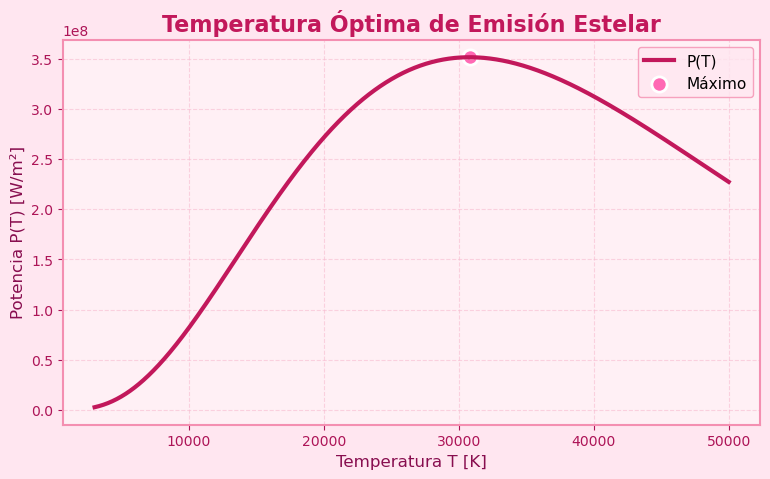

In [13]:
# Val
T_vals = np.linspace(3000, 50000, 1000)
P_vals = P(T_vals)

plt.figure(figsize=(9, 5), facecolor="#ffe6f0")

plt.plot(
    T_vals,
    P_vals,
    color="#c2185b",
    linewidth=3,
    label="P(T)"
)

# . max
plt.scatter(
    T_opt,
    P_max,
    color="#ff69b4",
    s=120,
    edgecolors="white",
    linewidths=2,
    label="Máximo"
)

plt.xlabel("Temperatura T [K]", fontsize=12, color="#880e4f")
plt.ylabel("Potencia P(T) [W/m²]", fontsize=12, color="#880e4f")

plt.title(
    "Temperatura Óptima de Emisión Estelar",
    fontsize=16,
    color="#c2185b",
    weight="bold"
)

ax = plt.gca()
ax.set_facecolor("#fff0f5")
plt.grid(color="#f8bbd0", linestyle="--", alpha=0.6)
for spine in ax.spines.values():
    spine.set_color("#f48fb1")
    spine.set_linewidth(1.5)
ax.tick_params(colors="#ad1457")
plt.legend(
    facecolor="#ffe6f0",
    edgecolor="#f48fb1",
    fontsize=11
)

plt.show()